Cargamos una pequeña parte de los datos y hacemos algunos calculos:


In [9]:
import pandas as pd
import glob

print("Cargando 3 archivos parquet pequeños para exploración...")

# recoger 3 ficheros
sample_files = glob.glob("/kaggle/input/smadex-challenge-predict-the-revenue/train/train/*/*.parquet")[:3]

dfs = []
for f in sample_files:
    print("Leyendo:", f)
    dfs.append(pd.read_parquet(f))

df_sample = pd.concat(dfs, ignore_index=True)

print("\nSample size:", df_sample.shape)
print("\nColumnas:")
print(df_sample.columns)

print("\nTipos de datos:")
print(df_sample.dtypes)

print("\nMissing (%):")
print(df_sample.isna().mean().sort_values(ascending=False).head(20))

print("\nDescribe:")
print(df_sample.describe())


Cargando 3 archivos parquet pequeños para exploración...
Leyendo: /kaggle/input/smadex-challenge-predict-the-revenue/train/train/datetime=2025-10-04-22-00/part-00195-32689ef5-2c84-4e68-a23b-394893039991.c000.snappy.parquet
Leyendo: /kaggle/input/smadex-challenge-predict-the-revenue/train/train/datetime=2025-10-06-21-00/part-00012-32689ef5-2c84-4e68-a23b-394893039991.c000.snappy.parquet
Leyendo: /kaggle/input/smadex-challenge-predict-the-revenue/train/train/datetime=2025-10-01-00-00/part-00314-32689ef5-2c84-4e68-a23b-394893039991.c000.snappy.parquet

Sample size: (373747, 84)

Columnas:
Index(['buyer_d1', 'buyer_d7', 'buyer_d14', 'buyer_d28', 'buy_d7', 'buy_d14',
       'buy_d28', 'iap_revenue_d7', 'iap_revenue_d14', 'iap_revenue_d28',
       'registration', 'retention_d1_to_d7', 'retention_d3_to_d7',
       'retention_d7_to_d14', 'retention_d1', 'retention_d3', 'retentiond7',
       'advertiser_bundle', 'advertiser_category', 'advertiser_subcategory',
       'advertiser_bottom_taxonomy

Ahora hacemos una limpieza de los datos que creemos como no relevantes:

In [11]:
import pandas as pd

df = df_sample.copy()

print("=== SHAPE DEL SAMPLE ===")
print(df.shape)


# 1. Columnas completamente inútiles (solo si tienen 100% missing)
cols_constant_or_all_missing = df.columns[df.isna().mean() == 1.0].tolist()

print("\n=== COLUMNAS 100% MISSING ===")
print(cols_constant_or_all_missing)

df.drop(columns=cols_constant_or_all_missing, errors="ignore", inplace=True)


# 2. Separar columnas densas y sparsas
dense_features = [
    "hour", "weekday", "avg_act_days", "avg_daily_sessions",
    "avg_duration", "weekend_ratio", "wifi_ratio",
    "weeks_since_first_seen", "release_msrp", "release_date"
]

dense_features = [c for c in dense_features if c in df.columns]

print("\n=== DENSE FEATURES (válidas para student) ===")
print(dense_features)


# detectar columnas muy sparsas
sparse_features = df.columns[df.isna().mean() > 0.90].tolist()

print("\n=== SPARSE FEATURES (>90% missing) ===")
print(sparse_features)


# teacher features: todas
teacher_features = list(df.columns)

print("\n=== TEACHER FEATURES (todas las columnas restantes) ===")
print(len(teacher_features), "columnas")


# student features: solo las densas + 3 categóricas simples
candidate_student_additional = ["country", "dev_os", "advertiser_category"]
student_features = dense_features + [c for c in candidate_student_additional if c in df.columns]

print("\n=== STUDENT FEATURES ===")
print(student_features)
print("\nNúmero total de features para student:", len(student_features))

=== SHAPE DEL SAMPLE ===
(373747, 84)

=== COLUMNAS 100% MISSING ===
[]

=== DENSE FEATURES (válidas para student) ===
['hour', 'weekday', 'avg_act_days', 'avg_daily_sessions', 'avg_duration', 'weekend_ratio', 'wifi_ratio', 'weeks_since_first_seen', 'release_msrp', 'release_date']

=== SPARSE FEATURES (>90% missing) ===
['avg_days_ins', 'ctr', 'ctr_pct_rk', 'iap_revenue_usd_bundle', 'iap_revenue_usd_category', 'iap_revenue_usd_category_bottom_taxonomy', 'last_buy', 'last_buy_ts_bundle', 'last_buy_ts_category', 'advertiser_actions_action_count', 'advertiser_actions_action_last_timestamp', 'last_advertiser_action', 'num_buys_bundle', 'num_buys_category', 'num_buys_category_bottom_taxonomy', 'rev_by_adv', 'whale_users_bundle_num_buys_prank', 'whale_users_bundle_revenue_prank', 'whale_users_bundle_total_num_buys', 'whale_users_bundle_total_revenue']

=== TEACHER FEATURES (todas las columnas restantes) ===
84 columnas

=== STUDENT FEATURES ===
['hour', 'weekday', 'avg_act_days', 'avg_daily_

EDA visualization:

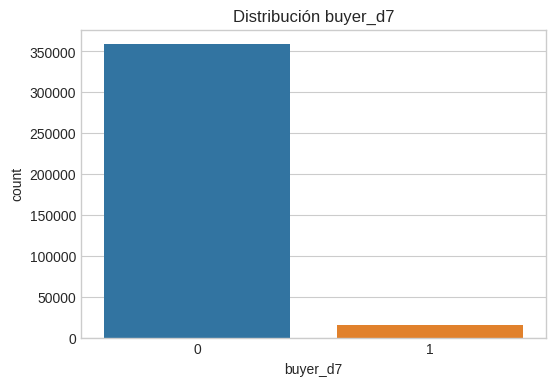

Ratio compradores d7: 0.04027590856916577


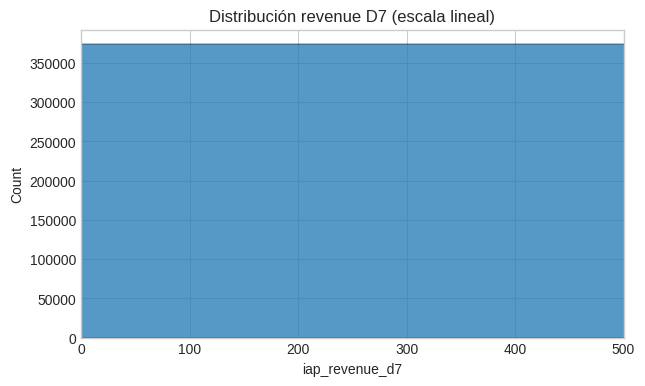

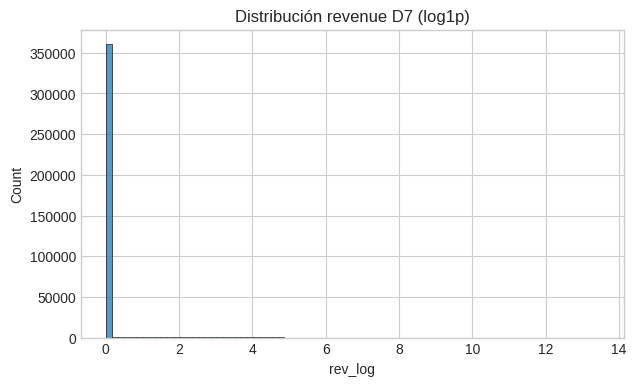

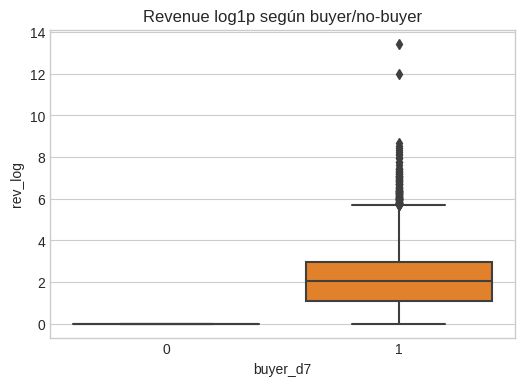

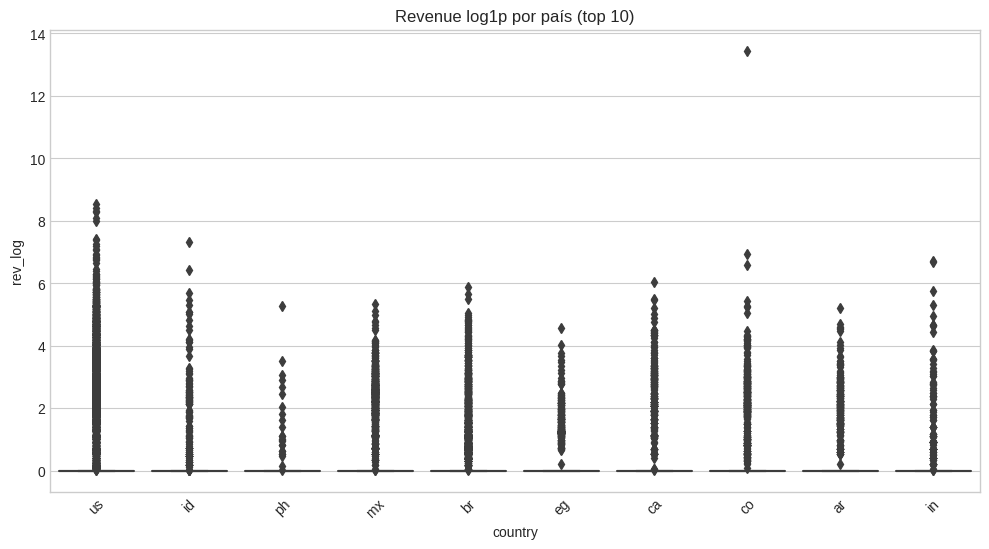

ValueError: setting an array element with a sequence.

<Figure size 800x600 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = df_sample.copy()

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================
# 1) Distribución de buyer_d7
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x=df["buyer_d7"])
plt.title("Distribución buyer_d7")
plt.show()

print("Ratio compradores d7:", df["buyer_d7"].mean())

# ============================================
# 2) Distribución revenue d7 (lineal)
# ============================================

plt.figure(figsize=(7,4))
sns.histplot(df["iap_revenue_d7"], bins=100, kde=False)
plt.title("Distribución revenue D7 (escala lineal)")
plt.xlim(0, 500)  # para ver algo (la mayoría son 0)
plt.show()

# ============================================
# 3) Distribución revenue d7 (log escalar)
# ============================================
df["rev_log"] = np.log1p(df["iap_revenue_d7"])

plt.figure(figsize=(7,4))
sns.histplot(df["rev_log"], bins=80, kde=False)
plt.title("Distribución revenue D7 (log1p)")
plt.show()

# ============================================
# 4) Histogramas buyers vs no buyers
# ============================================

plt.figure(figsize=(6,4))
sns.boxplot(x="buyer_d7", y="rev_log", data=df)
plt.title("Revenue log1p según buyer/no-buyer")
plt.show()

# ============================================
# 5) Revenue por país (top 10)
# ============================================

top_countries = df["country"].value_counts().index[:10]
df_top = df[df["country"].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.boxplot(x="country", y="rev_log", data=df_top)
plt.title("Revenue log1p por país (top 10)")
plt.xticks(rotation=45)
plt.show()

# ============================================
# 6) Heatmap de correlaciones densas
# ============================================

Seleccionar solo columnas numericas escalares
numeric_df = df.select_dtypes(include=["int16","int32","int64","float16","float32","float64"]).copy()

# Añadir rev_log si no está
if "rev_log" in df.columns and "rev_log" not in numeric_df.columns:
    numeric_df["rev_log"] = df["rev_log"]

# Filtrar columnas que tienen valores tipo lista (corrompen corr())
clean_numeric_cols = []
for col in numeric_df.columns:
    # excluir columnas donde al menos un valor es una lista
    if not numeric_df[col].apply(lambda x: isinstance(x, list)).any():
        clean_numeric_cols.append(col)

corr_df = numeric_df[clean_numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_df, annot=False, cmap="coolwarm")
plt.title("Correlación entre features numéricas limpias")
plt.show()
# ============================================
# 7) Revenue por hora del día
# ============================================

plt.figure(figsize=(8,4))
sns.lineplot(x="hour", y="rev_log", data=df)
plt.title("Revenue medio log1p según hour")
plt.show()

# ============================================
# 8) Revenue por categoría de app (top 10)
# ============================================

top_cat = df["advertiser_category"].value_counts().index[:10]
df_cat = df[df["advertiser_category"].isin(top_cat)]

plt.figure(figsize=(10,5))
sns.boxplot(x="advertiser_category", y="rev_log", data=df_cat)
plt.xticks(rotation=45)
plt.title("Revenue log1p por categoría (top 10)")
plt.show()